In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

In [2]:
df = pd.read_csv('nyc_bus_cleaned.csv')

In [3]:
# Datetime Object Conversion
df['RecordedAtTime'] = pd.to_datetime(df['RecordedAtTime'])
df['ExpectedArrivalTime'] = pd.to_datetime(df['ExpectedArrivalTime'])
df['Scheduled_dt'] = pd.to_datetime(df['Scheduled_dt'])

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21914630 entries, 0 to 21914629
Data columns (total 19 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   RecordedAtTime             datetime64[ns]
 1   DirectionRef               float64       
 2   PublishedLineName          object        
 3   OriginName                 object        
 4   OriginLat                  float64       
 5   OriginLong                 float64       
 6   DestinationName            object        
 7   DestinationLat             float64       
 8   DestinationLong            float64       
 9   VehicleRef                 object        
 10  VehicleLocation.Latitude   float64       
 11  VehicleLocation.Longitude  float64       
 12  NextStopPointName          object        
 13  ArrivalProximityText       object        
 14  DistanceFromStop           float64       
 15  ExpectedArrivalTime        datetime64[ns]
 16  ScheduledArrivalTime       object 

In [5]:
df['Month'] = df['RecordedAtTime'].dt.month
month_map = {6: 'June', 8: 'August', 10: 'October', 12: 'December'}
df['Month Name'] = df['Month'].map(month_map)
df = df[df['Month'].isin([6, 8, 10, 12])].copy()

month_order = ['June', 'August', 'October', 'December']
df['Month Name'] = pd.Categorical(df['Month Name'], categories=month_order, ordered=True)

In [6]:
# Count rows with positive delay per line per month
delay_counts = (
    df[df['delay_minutes'] > 0]
    .groupby(['Month Name', 'PublishedLineName'], observed=True)
    .size()
    .reset_index(name='DelayCount')
)

top5_lines = (
    delay_counts
    .sort_values(['Month Name', 'DelayCount'], ascending=[True, False])
    .groupby('Month Name', observed=True)
    .head(5)
    .reset_index(drop=True)
)

print(top5_lines)

   Month Name PublishedLineName  DelayCount
0        June               B41       77913
1        June                B6       73464
2        June               Q58       65389
3        June               B35       64930
4        June           Q44-SBS       64209
5      August               B41       69354
6      August                B6       57173
7      August               B35       56359
8      August           Q44-SBS       56132
9      August           M15-SBS       55239
10    October               B41       75494
11    October                B6       72777
12    October               Q58       66287
13    October               B35       65555
14    October           Q44-SBS       65118
15   December               B41       68235
16   December                B6       64559
17   December               B35       59674
18   December               Q58       58593
19   December           Q44-SBS       56489


In [7]:
top_line_names = top5_lines['PublishedLineName'].unique()
print(f"Top bus lines: {top_line_names}")

# Keep ALL rows (including negative delays) for these lines
df_top = df[df['PublishedLineName'].isin(top_line_names)].copy()

Top bus lines: ['B41' 'B6' 'Q58' 'B35' 'Q44-SBS' 'M15-SBS']


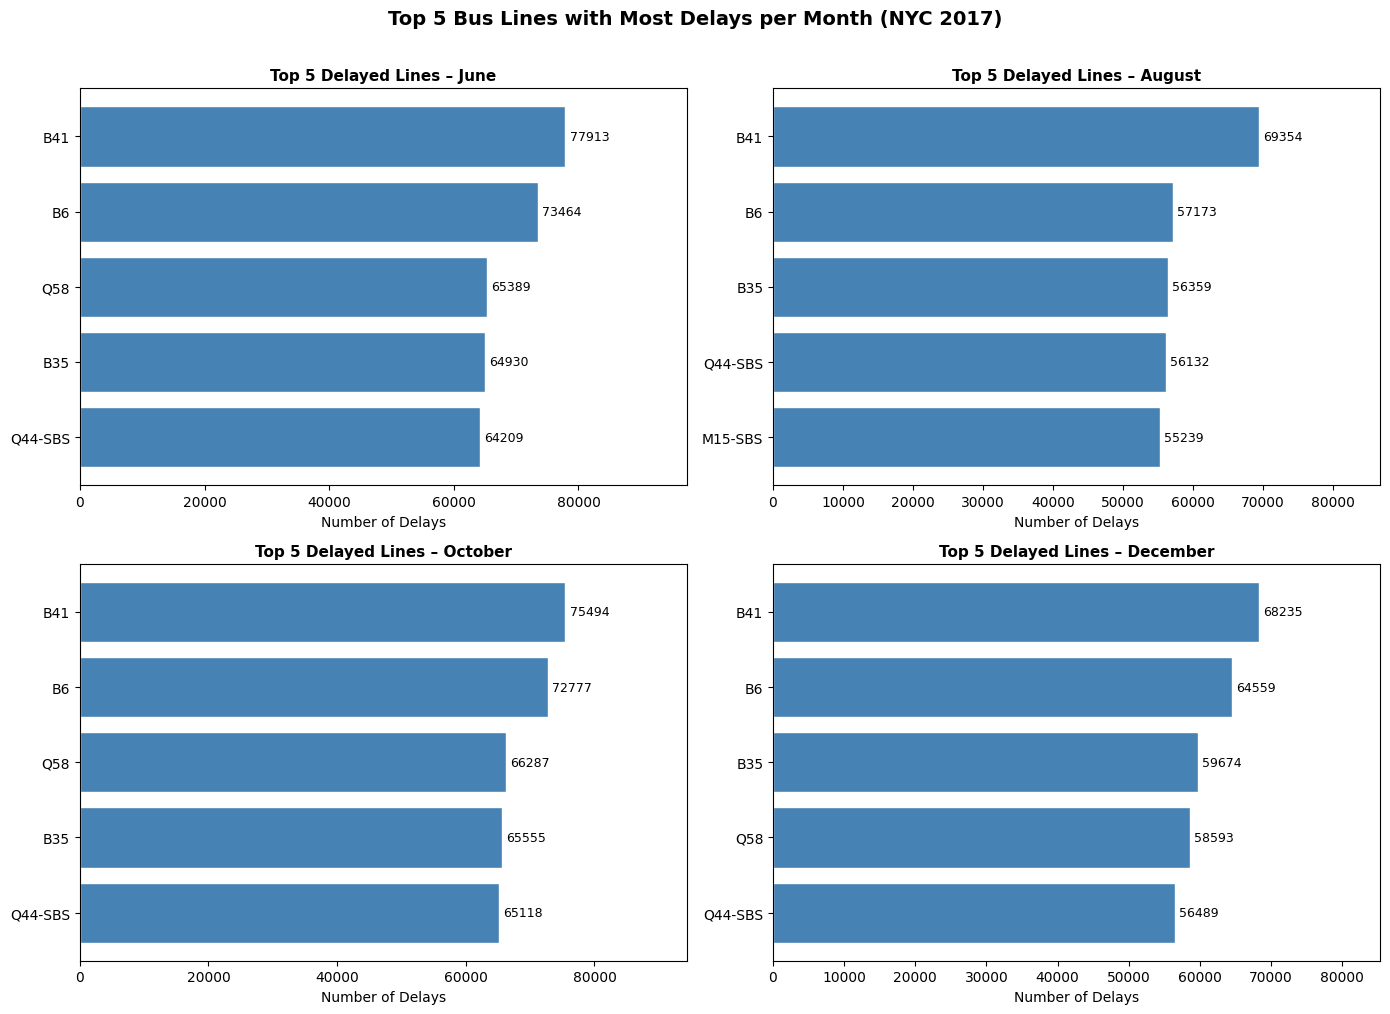

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, month in enumerate(month_order):
    data = top5_lines[top5_lines['Month Name'] == month].sort_values('DelayCount')
    ax = axes[i]
    bars = ax.barh(data['PublishedLineName'], data['DelayCount'], color='steelblue', edgecolor='white')
    ax.bar_label(bars, padding=3, fontsize=9)
    ax.set_title(f'Top 5 Delayed Lines – {month}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Number of Delays')
    ax.set_xlim(0, data['DelayCount'].max() * 1.25)

plt.suptitle('Top 5 Bus Lines with Most Delays per Month (NYC 2017)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("top5_delayed_lines.png", dpi=150, bbox_inches='tight')
plt.show()

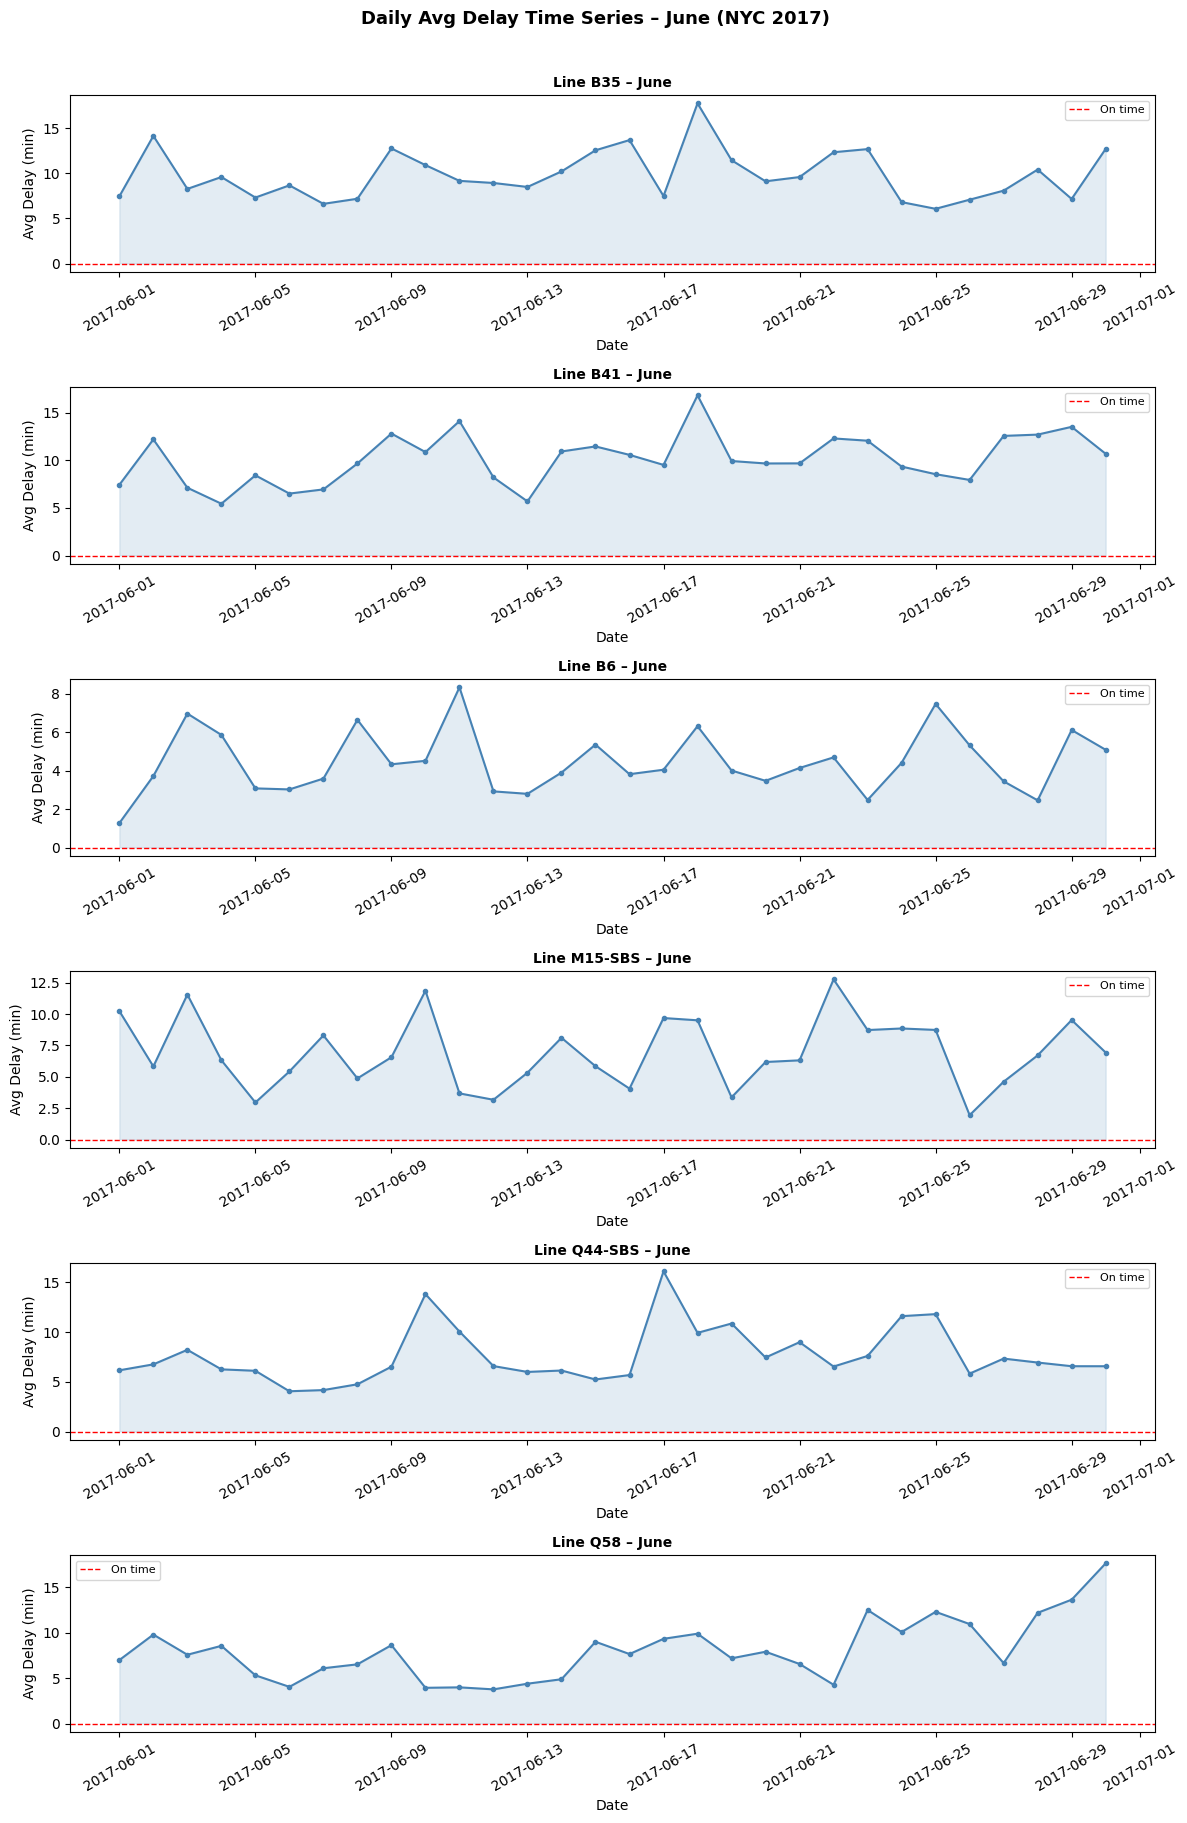

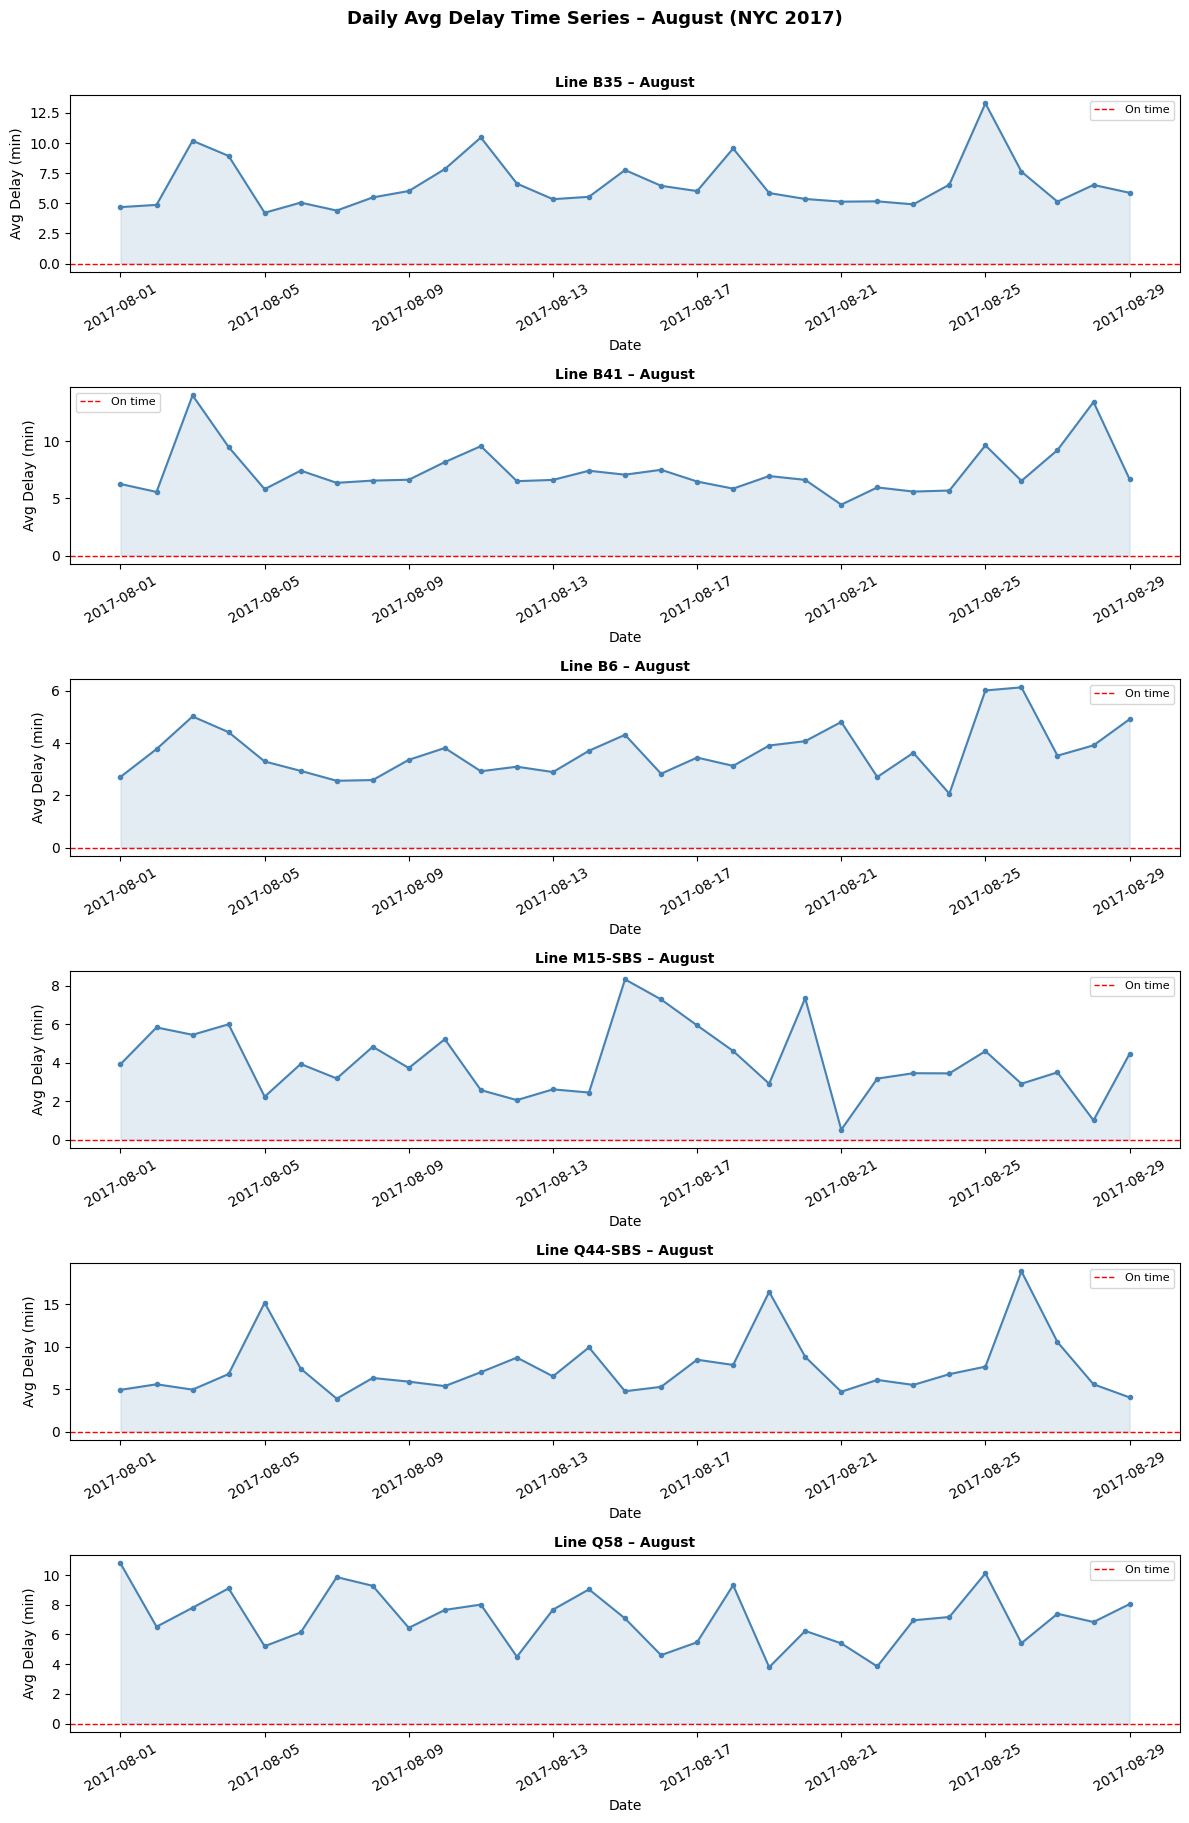

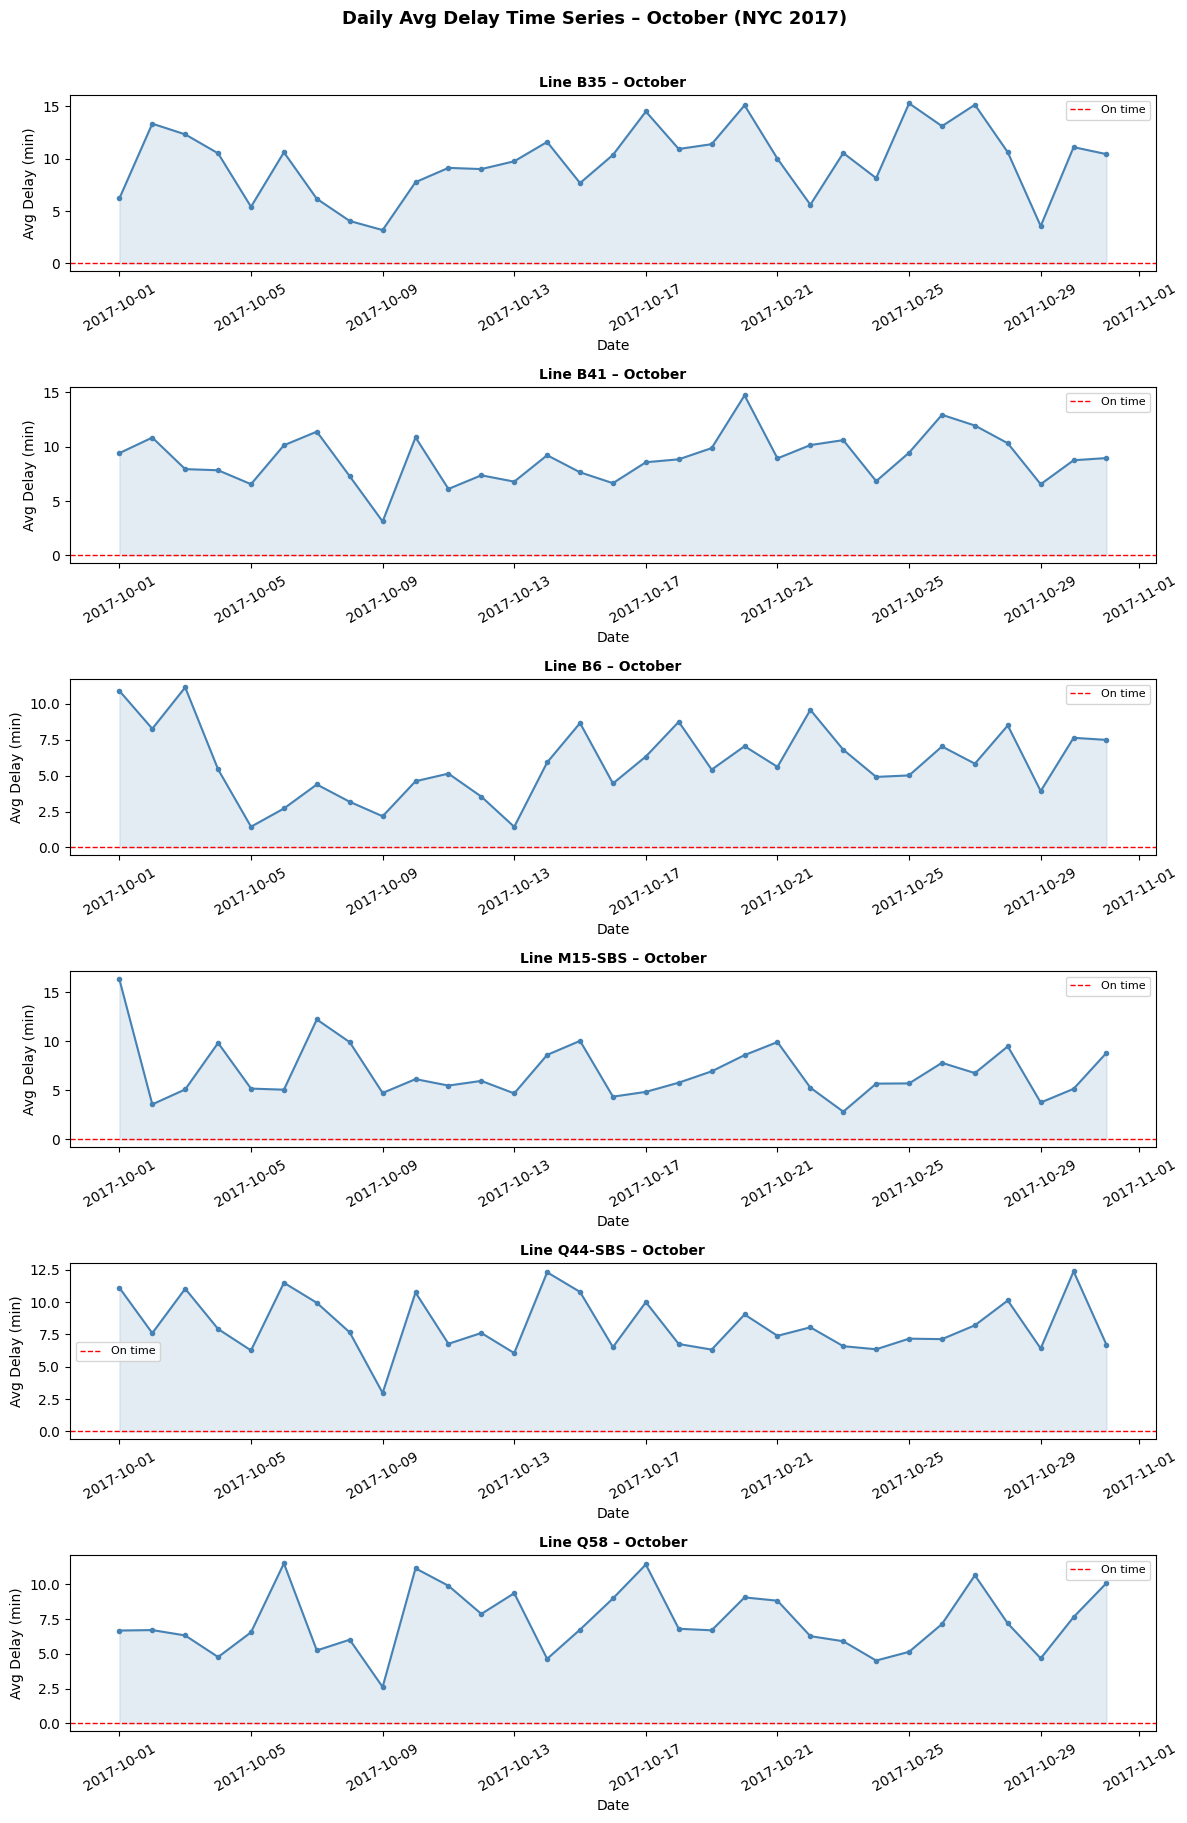

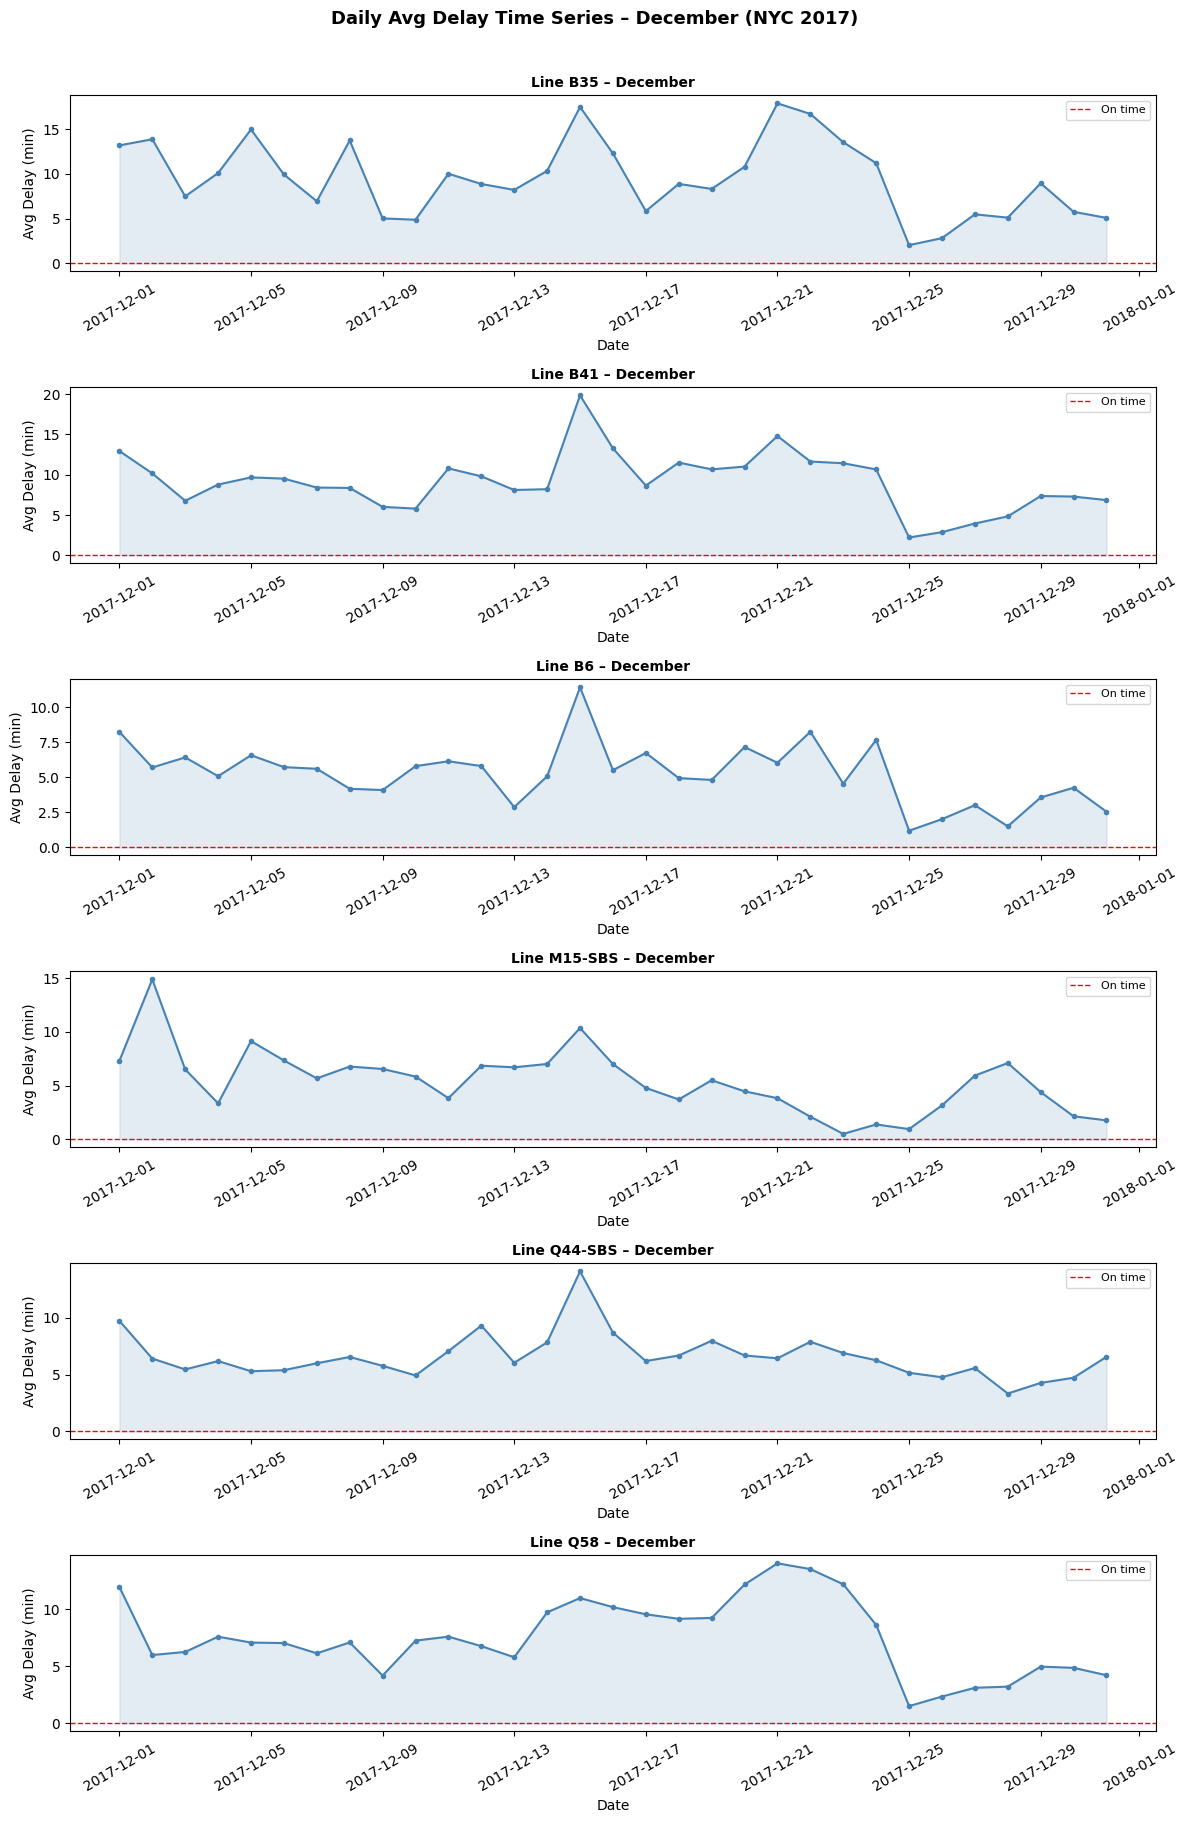

In [9]:
df_top['Date'] = df_top['RecordedAtTime'].dt.date

daily_delay = (
    df_top
    .groupby(['Month Name', 'PublishedLineName', 'Date'], observed=True)['delay_minutes']
    .mean()
    .reset_index()
)
daily_delay['Date'] = pd.to_datetime(daily_delay['Date'])

for month in month_order:
    month_data = daily_delay[daily_delay['Month Name'] == month]
    lines = month_data['PublishedLineName'].unique()

    fig, axes = plt.subplots(len(lines), 1, figsize=(12, 3 * len(lines)), sharex=False)
    if len(lines) == 1:
        axes = [axes]

    for ax, line in zip(axes, lines):
        line_data = month_data[month_data['PublishedLineName'] == line].sort_values('Date')
        ax.plot(line_data['Date'], line_data['delay_minutes'], color='steelblue', linewidth=1.5, marker='o', markersize=3)
        ax.fill_between(line_data['Date'], line_data['delay_minutes'], alpha=0.15, color='steelblue')
        ax.axhline(0, color='red', linestyle='--', linewidth=1, label='On time')
        ax.set_title(f'Line {line} – {month}', fontsize=10, fontweight='bold')
        ax.set_ylabel('Avg Delay (min)')
        ax.set_xlabel('Date')
        ax.tick_params(axis='x', rotation=30)
        ax.legend(fontsize=8)

    plt.suptitle(f'Daily Avg Delay Time Series – {month} (NYC 2017)', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f"delay_timeseries_{month.lower()}.png", dpi=150, bbox_inches='tight')
    plt.show()

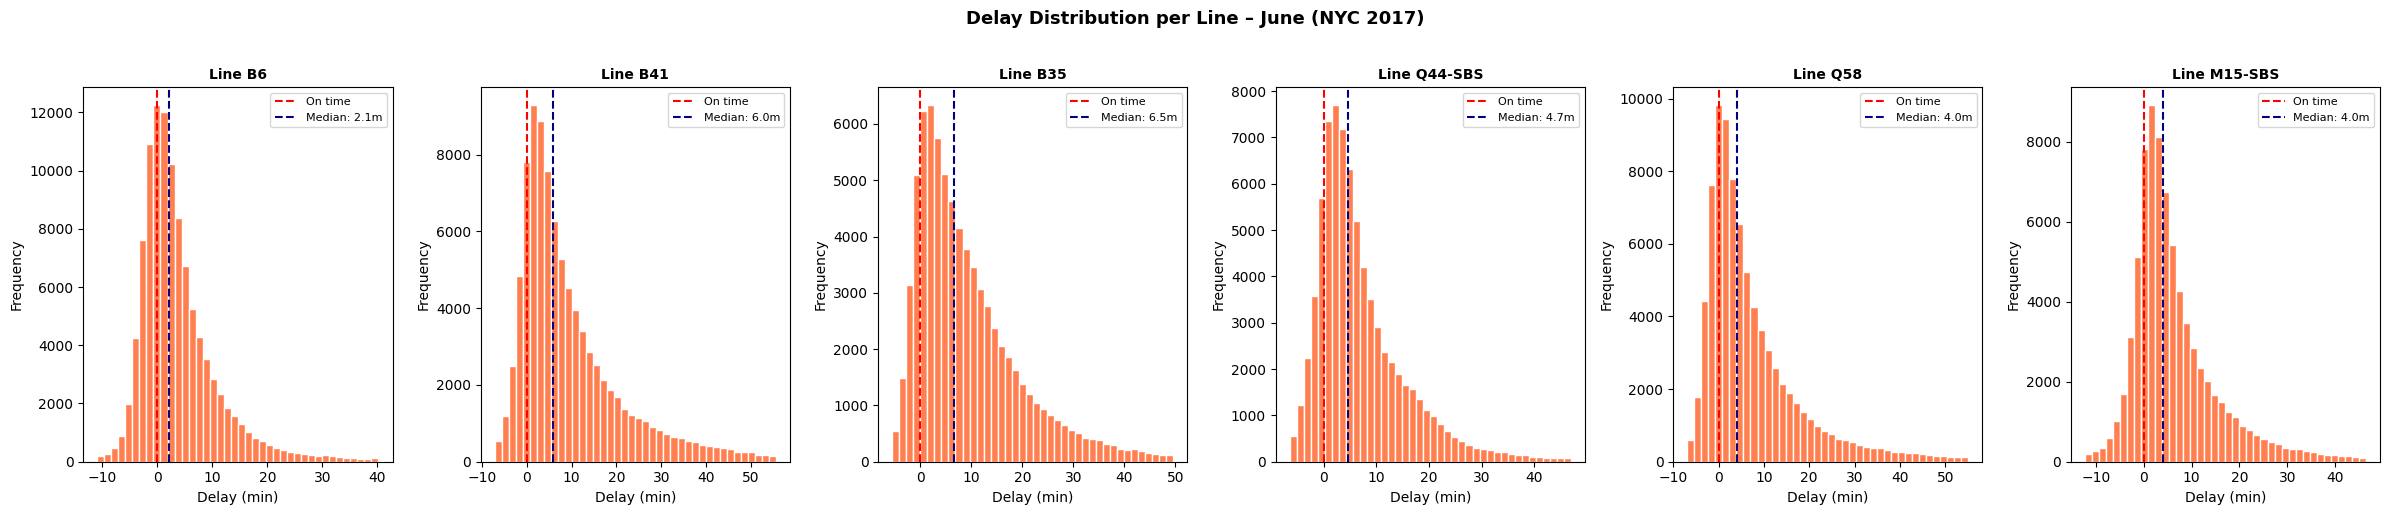

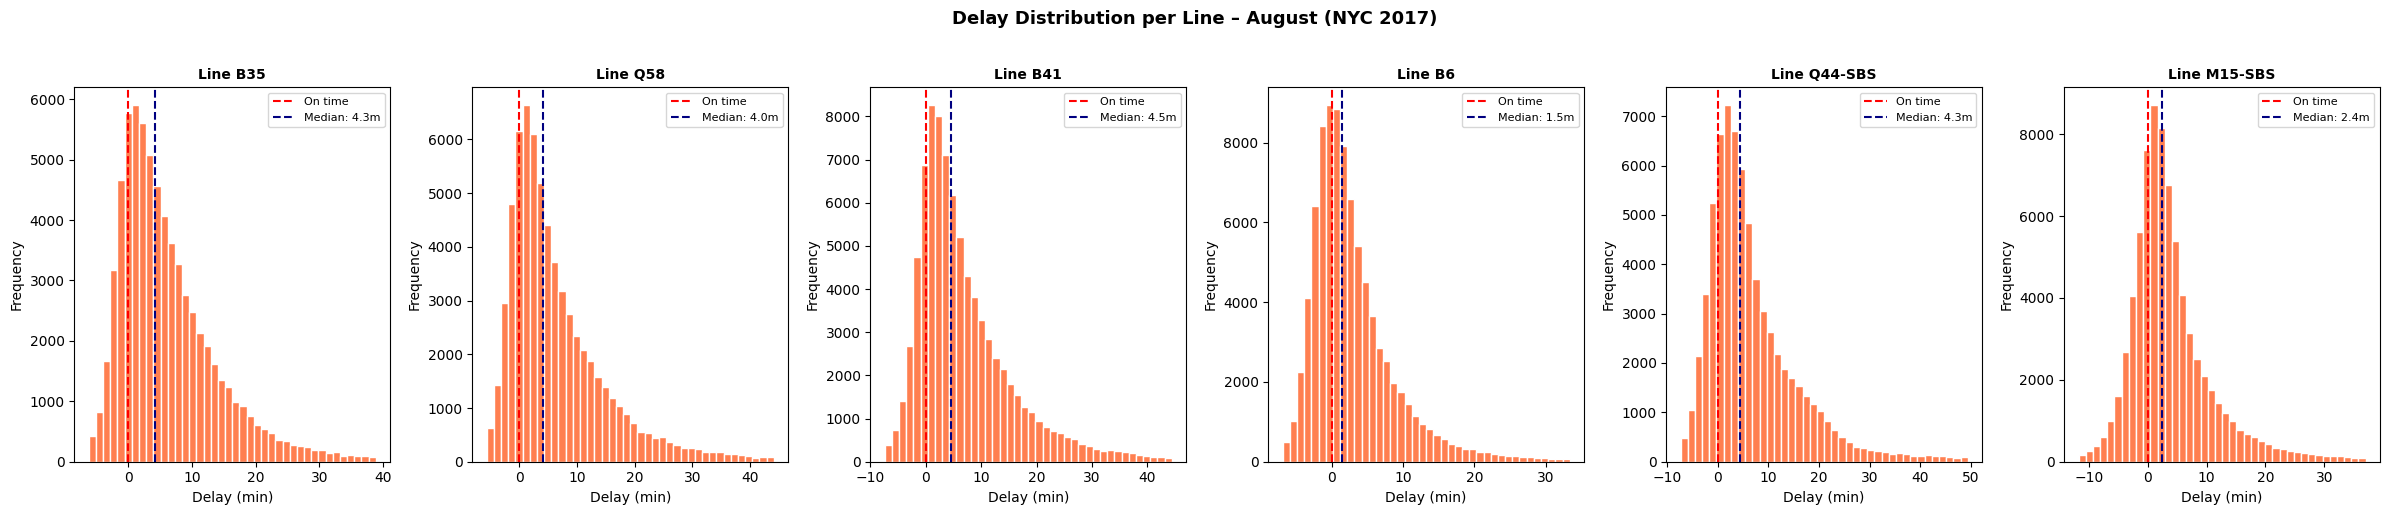

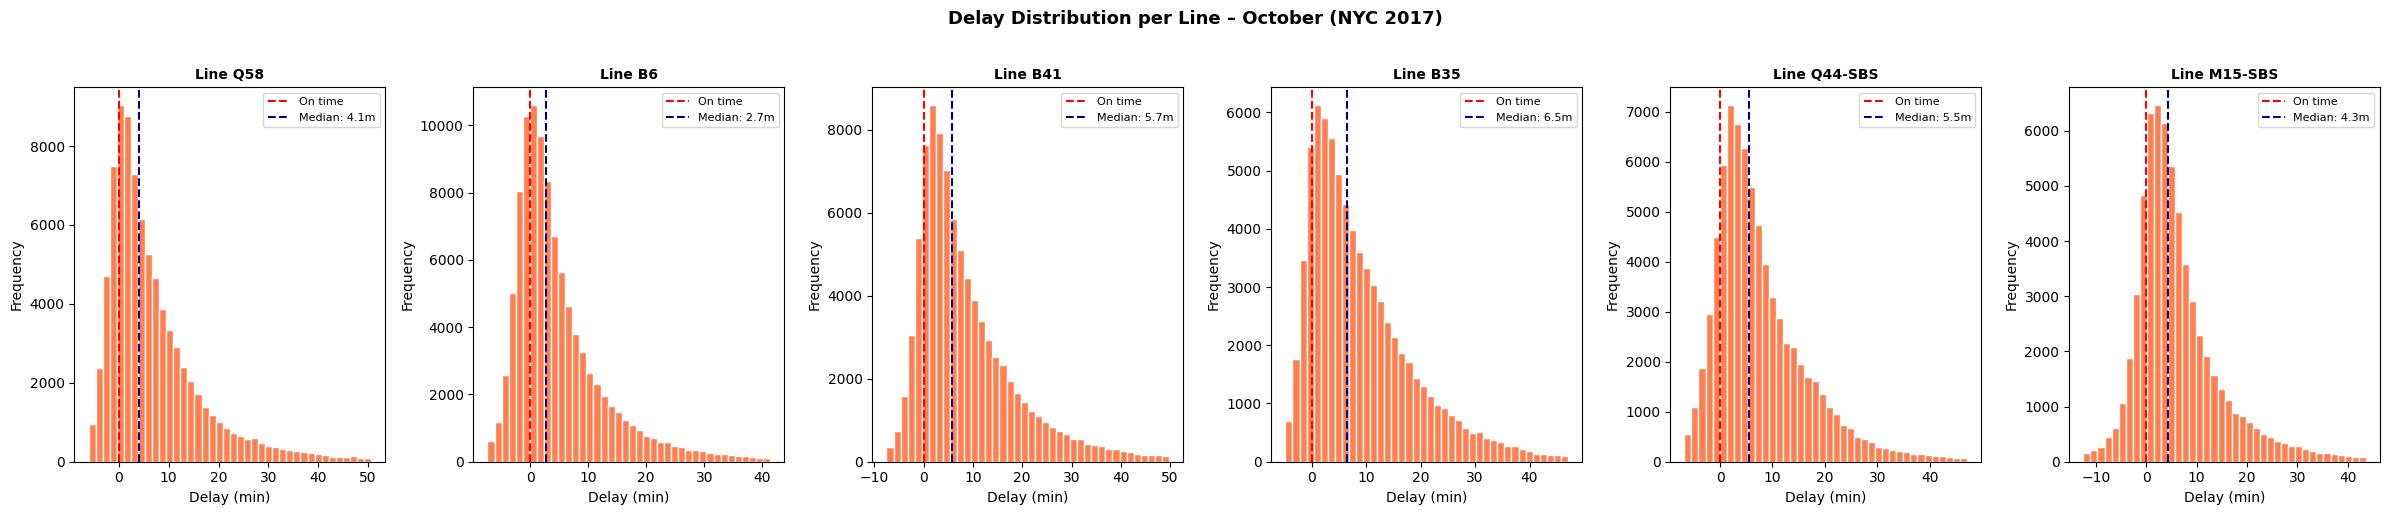

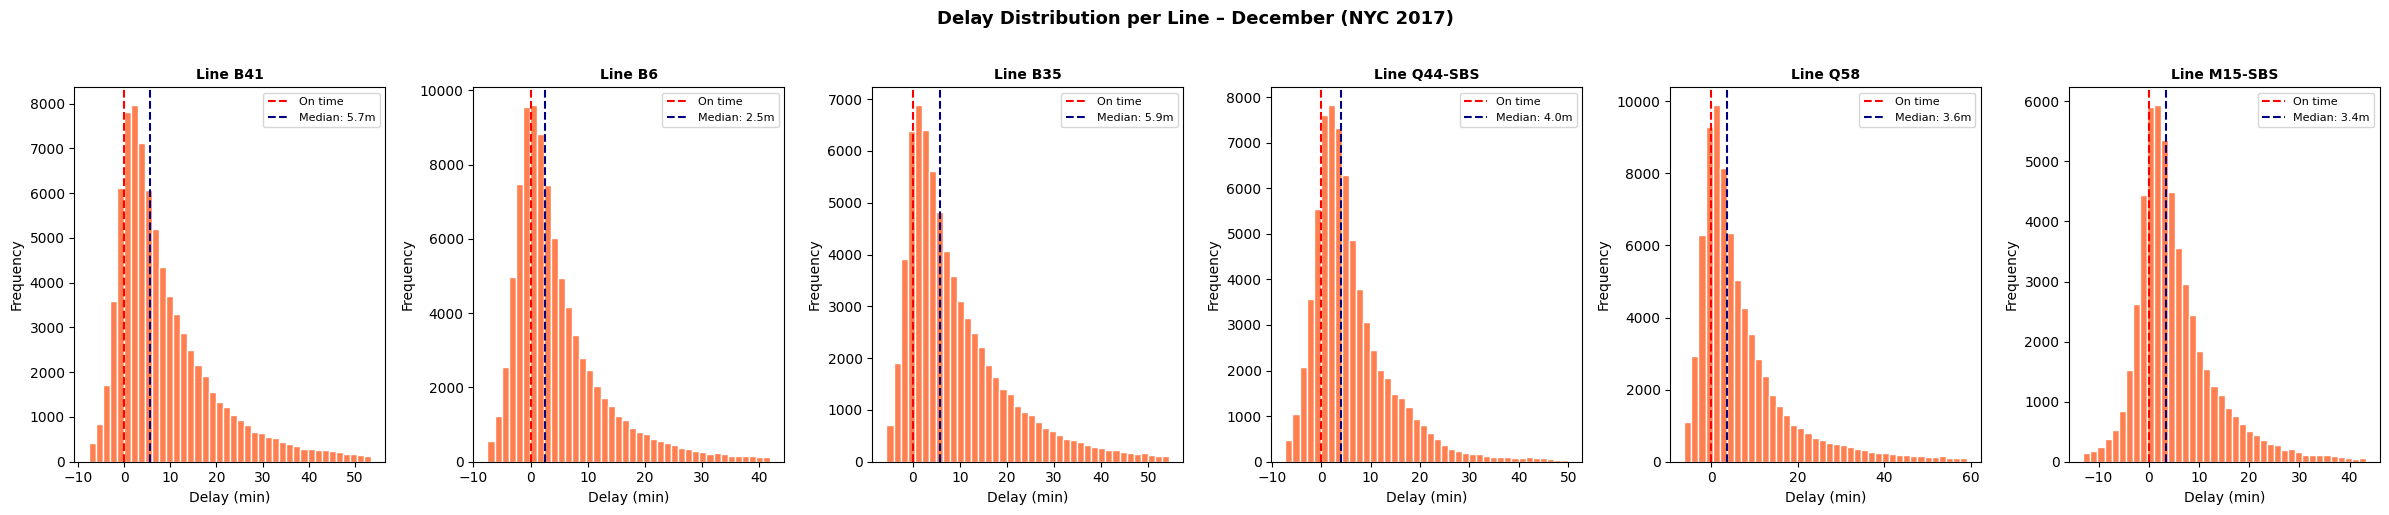

In [10]:
for month in month_order:
    month_data = df_top[df_top['Month Name'] == month]
    lines = month_data['PublishedLineName'].unique()

    fig, axes = plt.subplots(1, len(lines), figsize=(4 * len(lines), 5), sharey=False)
    if len(lines) == 1:
        axes = [axes]

    for ax, line in zip(axes, lines):
        line_data = month_data[month_data['PublishedLineName'] == line]['delay_minutes']
        # Cap at 1st and 99th percentile for cleaner visualization
        low, high = line_data.quantile(0.01), line_data.quantile(0.99)
        line_data_capped = line_data[(line_data >= low) & (line_data <= high)]
        ax.hist(line_data_capped, bins=40, color='coral', edgecolor='white')
        ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='On time')
        ax.axvline(line_data.median(), color='navy', linestyle='--', linewidth=1.5, label=f'Median: {line_data.median():.1f}m')
        ax.set_title(f'Line {line}', fontsize=10, fontweight='bold')
        ax.set_xlabel('Delay (min)')
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=8)

    plt.suptitle(f'Delay Distribution per Line – {month} (NYC 2017)', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f"delay_distribution_{month.lower()}.png", dpi=150, bbox_inches='tight')
    plt.show()

#### B41 Analysis

In [12]:
b41 = df[df['PublishedLineName'].str.contains('B41', na=False)].copy()
print(f"Total B41 rows: {b41.shape[0]:,}")
print(b41.groupby('Month Name', observed=True).size())

Total B41 rows: 348,053
Month Name
June        91776
August      85003
October     89319
December    81955
dtype: int64


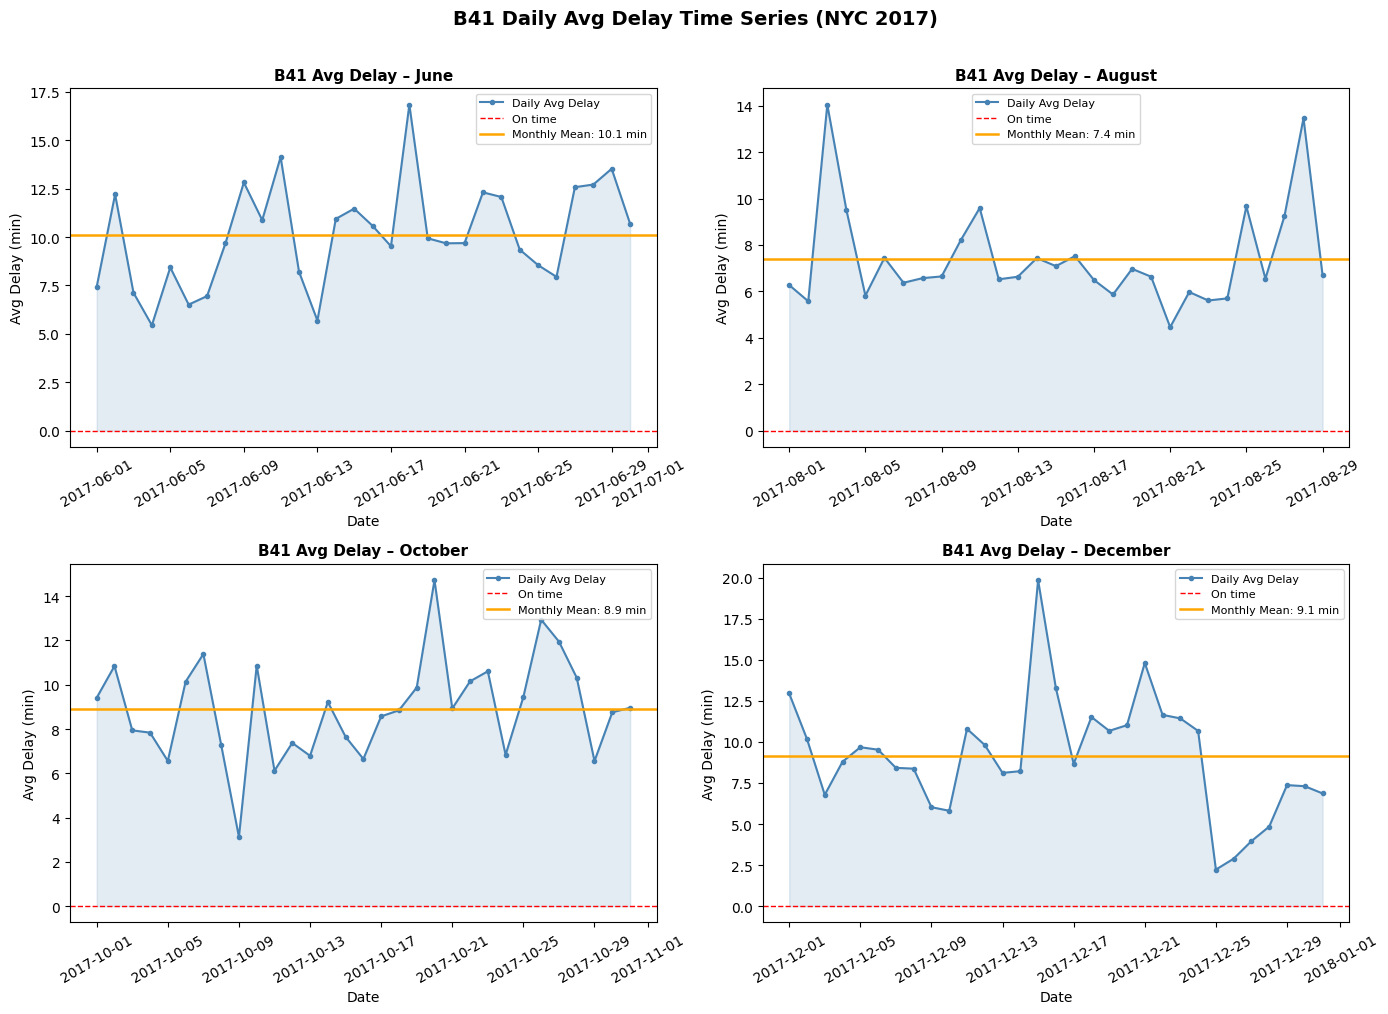

In [37]:
b41['Date'] = b41['RecordedAtTime'].dt.date
daily = b41.groupby(['Month Name', 'Date'], observed=True)['delay_minutes'].mean().reset_index()
daily['Date'] = pd.to_datetime(daily['Date'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, month in enumerate(month_order):
    data = daily[daily['Month Name'] == month].sort_values('Date')
    month_mean = data['delay_minutes'].mean()
    ax = axes[i]
    ax.plot(data['Date'], data['delay_minutes'], color='steelblue', linewidth=1.5, marker='o', markersize=3, label='Daily Avg Delay')
    ax.fill_between(data['Date'], data['delay_minutes'], alpha=0.15, color='steelblue')
    ax.axhline(0, color='red', linestyle='--', linewidth=1, label='On time')
    ax.axhline(month_mean, color='orange', linestyle='-', linewidth=1.8, label=f'Monthly Mean: {month_mean:.1f} min')
    ax.set_title(f'B41 Avg Delay – {month}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Avg Delay (min)')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

plt.suptitle('B41 Daily Avg Delay Time Series (NYC 2017)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("b41_timeseries.png", dpi=150, bbox_inches='tight')
plt.show()

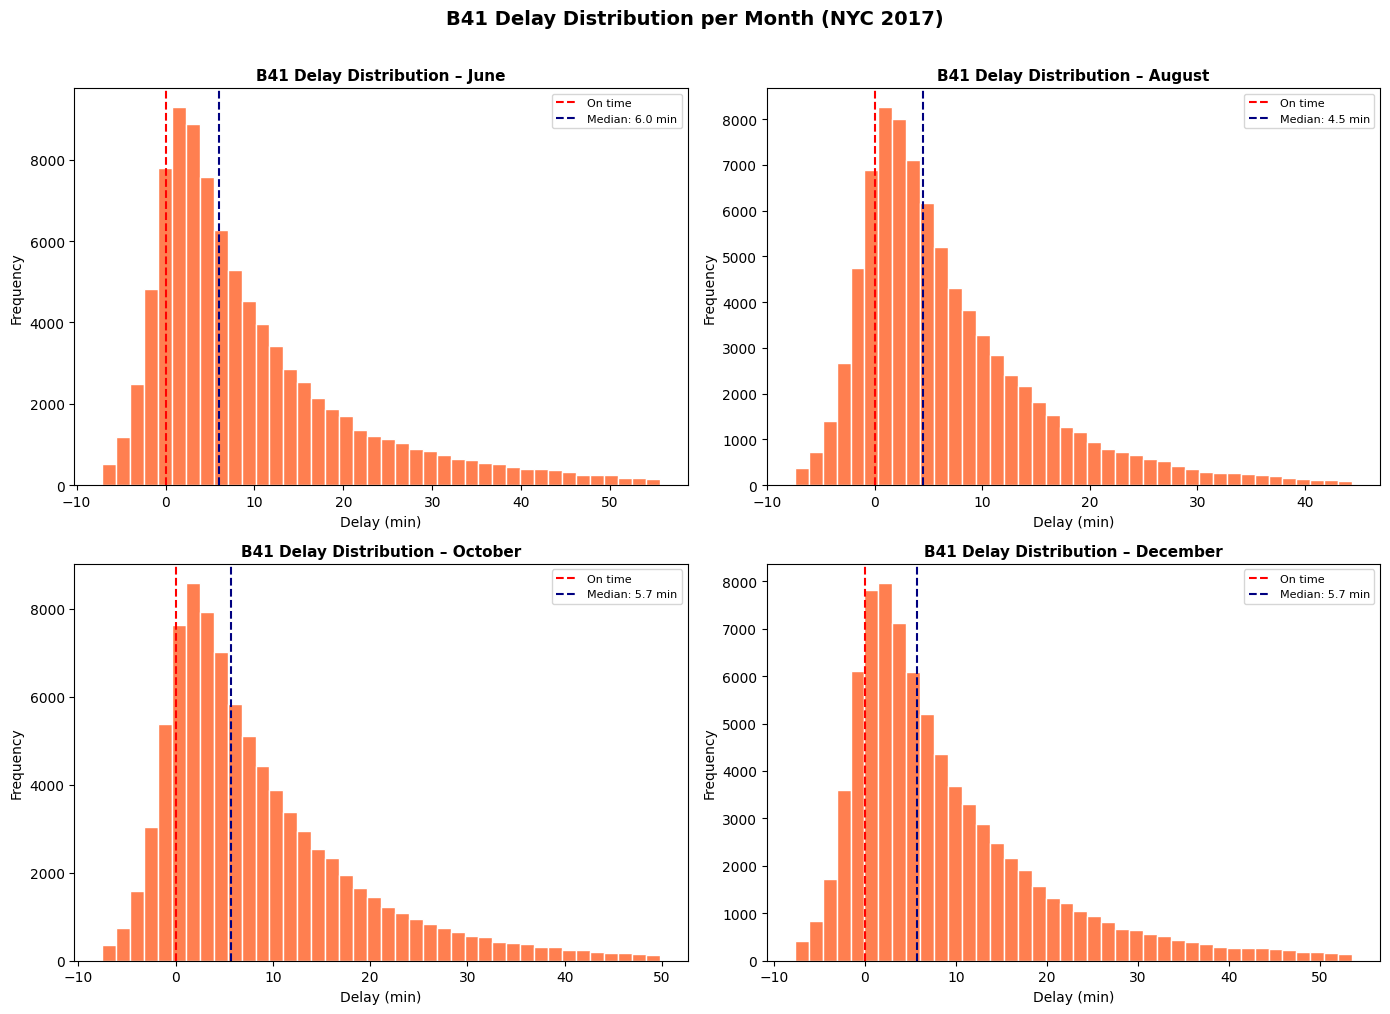

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, month in enumerate(month_order):
    data = b41[b41['Month Name'] == month]['delay_minutes']
    low, high = data.quantile(0.01), data.quantile(0.99)
    data_capped = data[(data >= low) & (data <= high)]
    ax = axes[i]b41['Hour'] = b41['RecordedAtTime'].dt.hour

hourly = b41.groupby(['Month Name', 'Hour'], observed=True)['delay_minutes'].mean().reset_index()
hourly_pivot = hourly.pivot(index='Month Name', columns='Hour', values='delay_minutes')
hourly_pivot = hourly_pivot.reindex(month_order)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(hourly_pivot.values, aspect='auto', cmap='RdYlGn_r')
ax.set_xticks(range(24))
ax.set_xticklabels(range(24))
ax.set_yticks(range(len(month_order)))
ax.set_yticklabels(month_order)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Month')
ax.set_title('B41 Avg Delay by Hour & Month (NYC 2017)', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label='Avg Delay (min)')
plt.tight_layout()
plt.savefig("b41_hourly_heatmap.png", dpi=150)
plt.show()
    ax.hist(data_capped, bins=40, color='coral', edgecolor='white')
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='On time')
    ax.axvline(data.median(), color='navy', linestyle='--', linewidth=1.5, label=f'Median: {data.median():.1f} min')
    ax.set_title(f'B41 Delay Distribution – {month}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Delay (min)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.suptitle('B41 Delay Distribution per Month (NYC 2017)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("b41_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

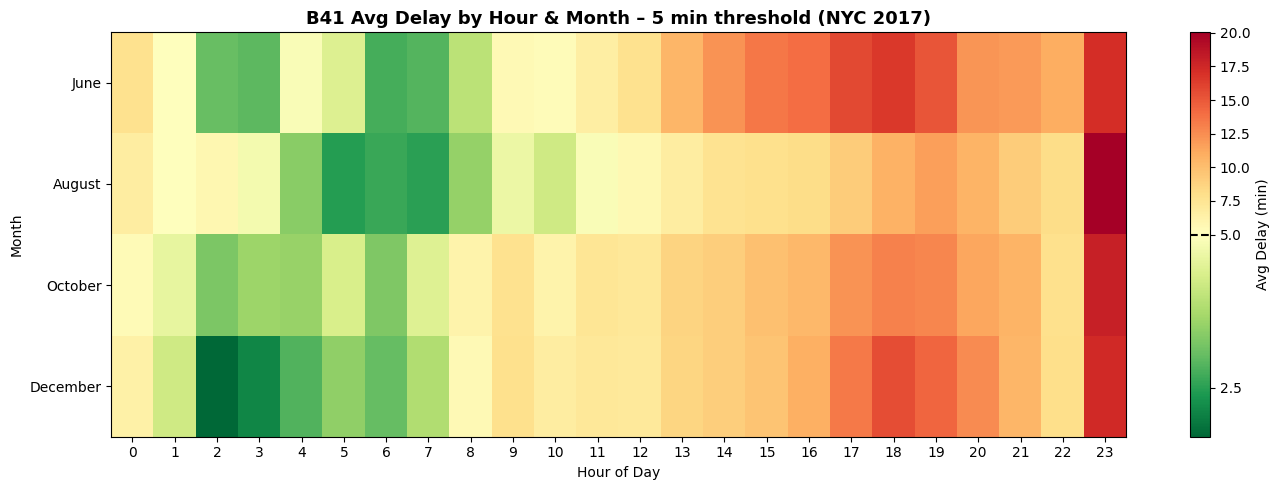

In [42]:
b41['Hour'] = b41['RecordedAtTime'].dt.hour

hourly = b41.groupby(['Month Name', 'Hour'], observed=True)['delay_minutes'].mean().reset_index()
hourly_pivot = hourly.pivot(index='Month Name', columns='Hour', values='delay_minutes')
hourly_pivot = hourly_pivot.reindex(month_order)

# Set transition: green below 5 min, red above 5 min
vmin = hourly_pivot.values.min()
vmax = hourly_pivot.values.max()
threshold = 5.0

# Normalize so that 5 min sits at the green-to-red boundary
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=threshold, vmax=vmax)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(hourly_pivot.values, aspect='auto', cmap='RdYlGn_r', norm=norm)
ax.set_xticks(range(24))
ax.set_xticklabels(range(24))
ax.set_yticks(range(len(month_order)))
ax.set_yticklabels(month_order)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Month')
ax.set_title('B41 Avg Delay by Hour & Month – 5 min threshold (NYC 2017)', fontsize=13, fontweight='bold')

cbar = plt.colorbar(im, ax=ax, label='Avg Delay (min)')
cbar.ax.axhline(threshold, color='black', linewidth=1.5, linestyle='--')

plt.tight_layout()
plt.savefig("b41_hourly_heatmap.png", dpi=150)
plt.show()

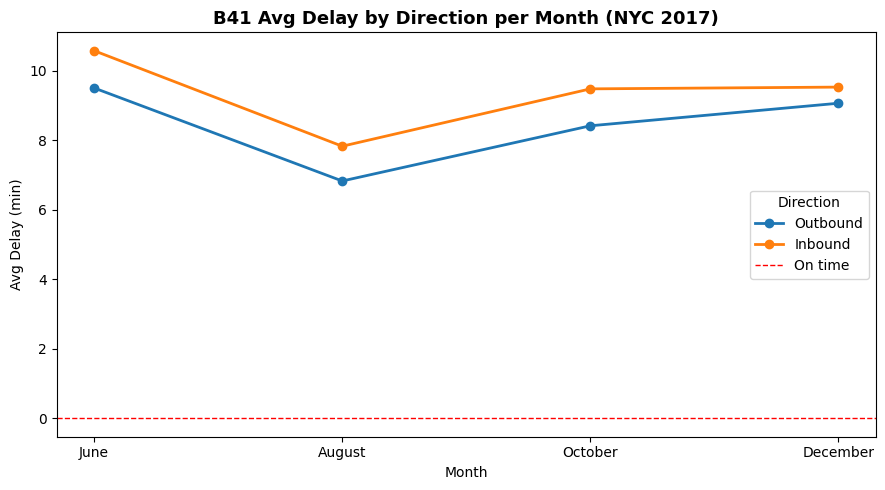

In [43]:
dir_delay = b41.groupby(['Month Name', 'DirectionRef'], observed=True)['delay_minutes'].mean().reset_index()
dir_delay['DirectionRef'] = dir_delay['DirectionRef'].map({0.0: 'Outbound', 1.0: 'Inbound'}).fillna(dir_delay['DirectionRef'].astype(str))

fig, ax = plt.subplots(figsize=(9, 5))
for direction in dir_delay['DirectionRef'].unique():
    d = dir_delay[dir_delay['DirectionRef'] == direction]
    ax.plot(d['Month Name'], d['delay_minutes'], marker='o', linewidth=2, label=direction)

ax.axhline(0, color='red', linestyle='--', linewidth=1, label='On time')
ax.set_title('B41 Avg Delay by Direction per Month (NYC 2017)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Delay (min)')
ax.legend(title='Direction')
plt.tight_layout()
plt.savefig("b41_direction_delay.png", dpi=150)
plt.show()

#### Manhatan Area Delay Rank

In [28]:
unique_lines = df['PublishedLineName'].dropna().unique()
unique_lines_sorted = sorted(unique_lines)

print(f"Total unique bus lines: {len(unique_lines_sorted)}")
print("\nAll unique bus lines:")
for line in unique_lines_sorted:
    print(line)

Total unique bus lines: 242

All unique bus lines:
B1
B11
B12
B13
B14
B15
B16
B17
B2
B20
B24
B25
B26
B3
B31
B32
B35
B36
B37
B38
B39
B4
B41
B42
B43
B44
B44-SBS
B45
B46
B46-SBS
B47
B48
B49
B52
B54
B57
B6
B60
B61
B62
B63
B64
B65
B67
B68
B69
B7
B70
B74
B8
B82
B83
B84
B9
Bx1
Bx10
Bx11
Bx12
Bx12-SBS
Bx13
Bx15
Bx16
Bx17
Bx18
Bx19
Bx2
Bx20
Bx21
Bx22
Bx24
Bx26
Bx27
Bx28
Bx29
Bx3
Bx30
Bx31
Bx32
Bx33
Bx34
Bx35
Bx36
Bx38
Bx39
Bx4
Bx40
Bx41
Bx41-SBS
Bx42
Bx46
Bx4A
Bx5
Bx6
Bx6-SBS
Bx7
Bx8
Bx9
M Shuttle Bus
M1
M10
M100
M101
M102
M103
M104
M106
M11
M116
M12
M14A
M14D
M15
M15-SBS
M2
M20
M21
M22
M23-SBS
M3
M31
M34-SBS
M34A-SBS
M35
M4
M42
M5
M50
M55
M57
M60-SBS
M66
M7
M72
M79-SBS
M8
M86-SBS
M9
M96
M98
Q1
Q12
Q13
Q15
Q15A
Q16
Q17
Q2
Q20A
Q20B
Q24
Q26
Q27
Q28
Q3
Q30
Q31
Q32
Q36
Q4
Q42
Q43
Q44-SBS
Q46
Q48
Q5
Q54
Q55
Q56
Q58
Q59
Q76
Q77
Q83
Q84
Q85
Q88
S40
S42
S44
S46
S48
S51
S52
S53
S54
S55
S56
S57
S59
S61
S62
S66
S74
S76
S78
S79-SBS
S81
S84
S86
S89
S90
S91
S92
S93
S94
S96
S98
Shuttle-M
Shuttle-M1
Shuttle-M

In [29]:
lines_to_check = ['M2', 'M3']

for line in lines_to_check:
    matches = [l for l in unique_lines_sorted if line in l]
    if matches:
        print(f"✓ '{line}' found: {matches}")
    else:
        print(f"✗ '{line}' NOT found in dataset")

✓ 'M2' found: ['M2', 'M20', 'M21', 'M22', 'M23-SBS', 'Shuttle-M2']
✓ 'M3' found: ['M3', 'M31', 'M34-SBS', 'M34A-SBS', 'M35', 'Shuttle-M3']


#### M2

In [32]:
m2 = df[df['PublishedLineName'] == 'M2'].copy()
print(f"Total exact M2 rows: {m2.shape[0]:,}")

Total exact M2 rows: 147,849


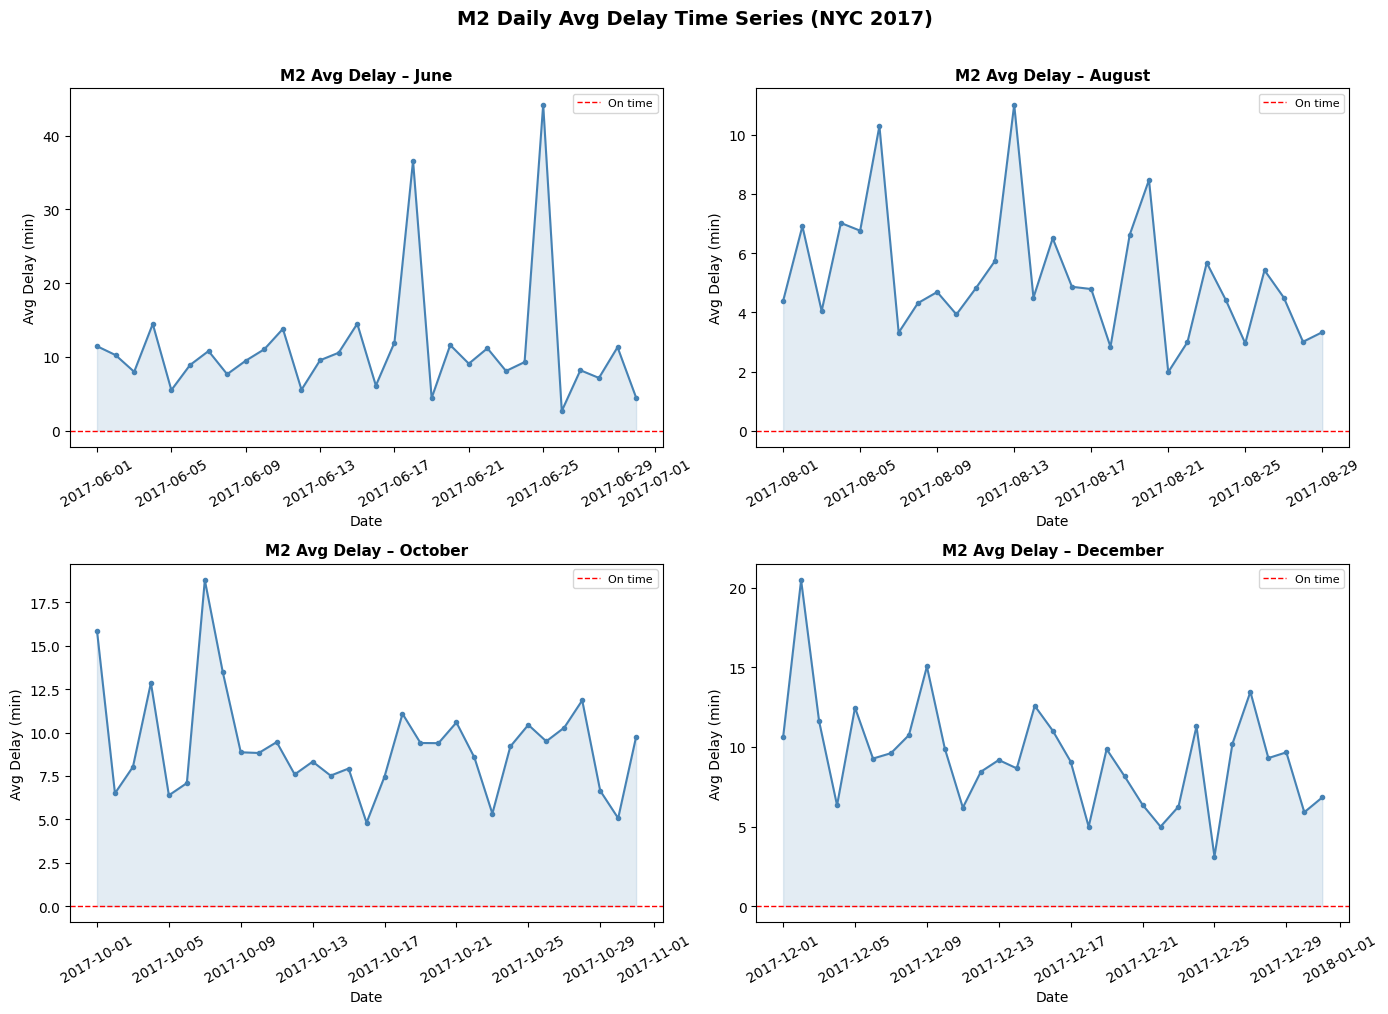

In [33]:
m2['Date'] = m2['RecordedAtTime'].dt.date
daily = m2.groupby(['Month Name', 'Date'], observed=True)['delay_minutes'].mean().reset_index()
daily['Date'] = pd.to_datetime(daily['Date'])

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, month in enumerate(month_order):
    data = daily[daily['Month Name'] == month].sort_values('Date')
    ax = axes[i]
    ax.plot(data['Date'], data['delay_minutes'], color='steelblue', linewidth=1.5, marker='o', markersize=3)
    ax.fill_between(data['Date'], data['delay_minutes'], alpha=0.15, color='steelblue')
    ax.axhline(0, color='red', linestyle='--', linewidth=1, label='On time')
    ax.set_title(f'M2 Avg Delay – {month}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Avg Delay (min)')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=8)

plt.suptitle('M2 Daily Avg Delay Time Series (NYC 2017)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("m2_timeseries.png", dpi=150, bbox_inches='tight')
plt.show()

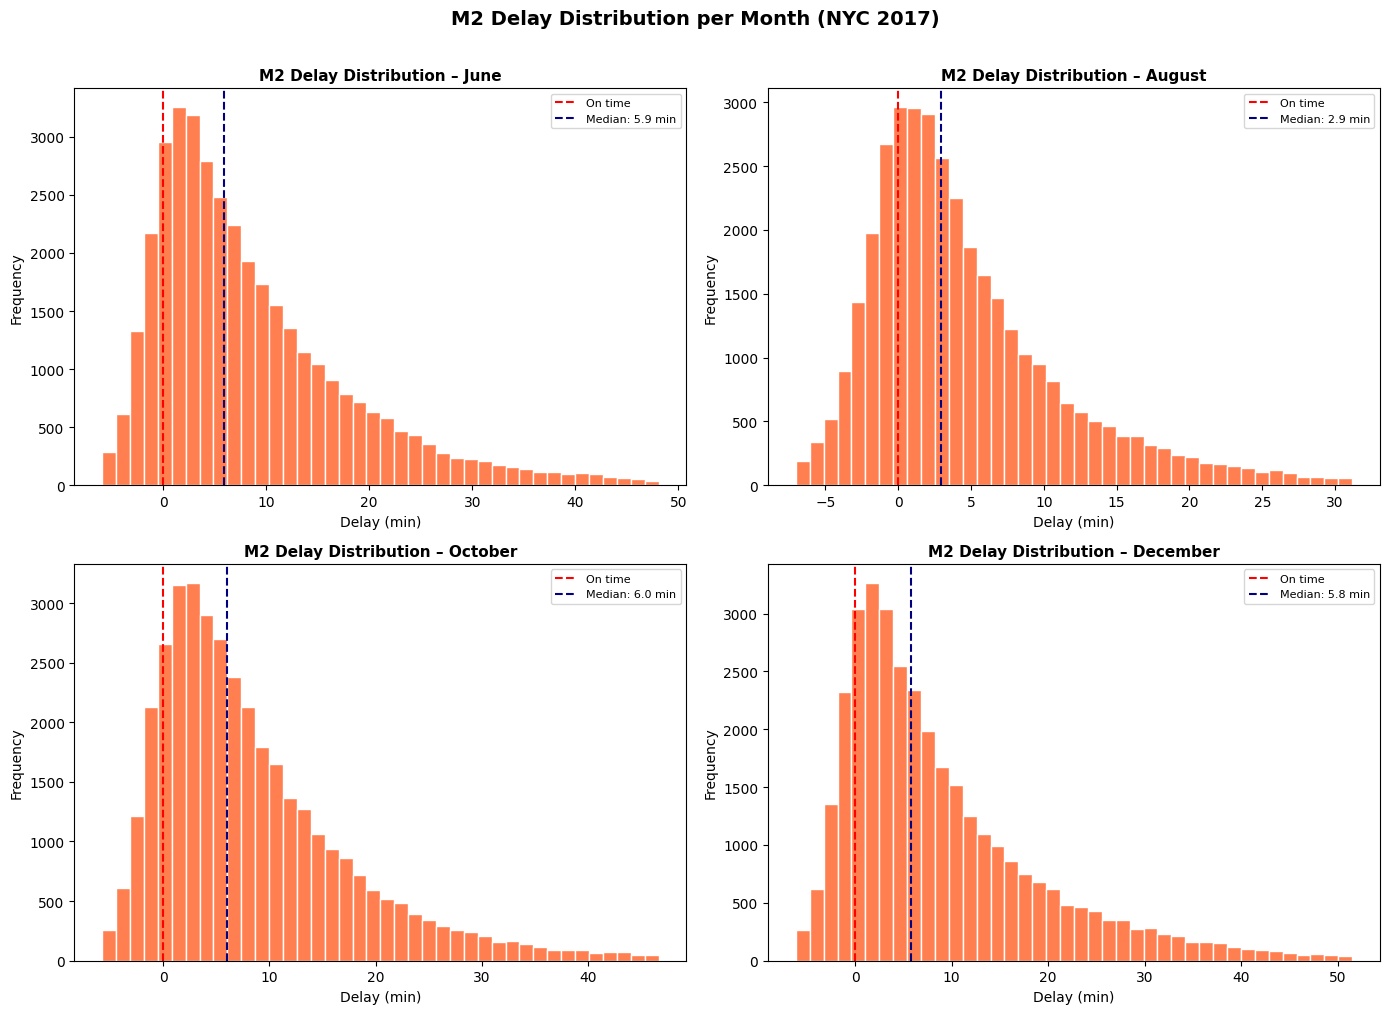

In [34]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, month in enumerate(month_order):
    data = m2[m2['Month Name'] == month]['delay_minutes']
    low, high = data.quantile(0.01), data.quantile(0.99)
    data_capped = data[(data >= low) & (data <= high)]
    ax = axes[i]
    ax.hist(data_capped, bins=40, color='coral', edgecolor='white')
    ax.axvline(0, color='red', linestyle='--', linewidth=1.5, label='On time')
    ax.axvline(data.median(), color='navy', linestyle='--', linewidth=1.5, label=f'Median: {data.median():.1f} min')
    ax.set_title(f'M2 Delay Distribution – {month}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Delay (min)')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.suptitle('M2 Delay Distribution per Month (NYC 2017)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("m2_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

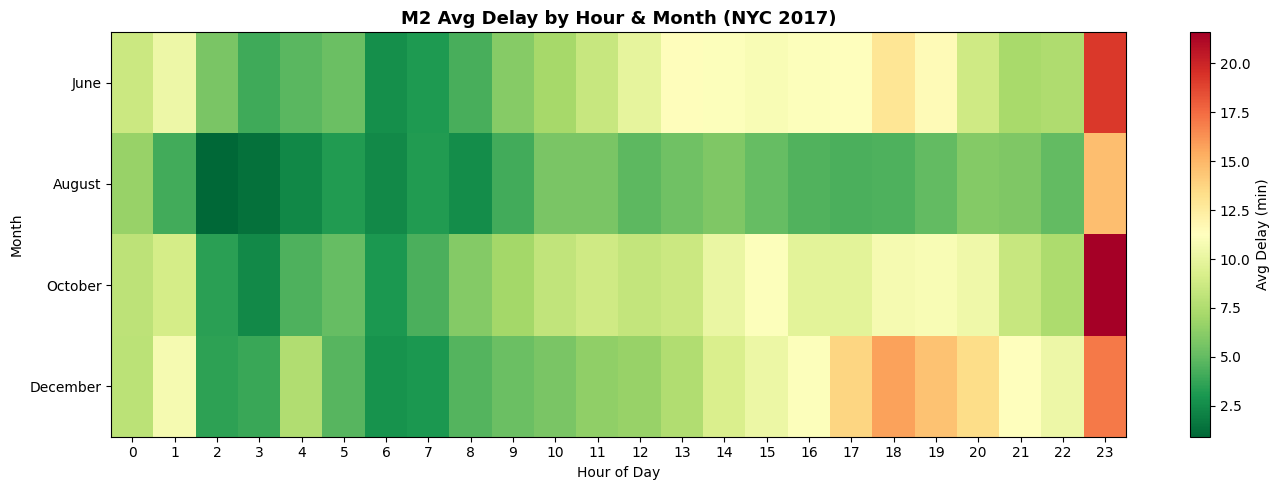

In [35]:
m2['Hour'] = m2['RecordedAtTime'].dt.hour

hourly = m2.groupby(['Month Name', 'Hour'], observed=True)['delay_minutes'].mean().reset_index()
hourly_pivot = hourly.pivot(index='Month Name', columns='Hour', values='delay_minutes')
hourly_pivot = hourly_pivot.reindex(month_order)

fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(hourly_pivot.values, aspect='auto', cmap='RdYlGn_r')
ax.set_xticks(range(24))
ax.set_xticklabels(range(24))
ax.set_yticks(range(len(month_order)))
ax.set_yticklabels(month_order)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Month')
ax.set_title('M2 Avg Delay by Hour & Month (NYC 2017)', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label='Avg Delay (min)')
plt.tight_layout()
plt.savefig("m2_hourly_heatmap.png", dpi=150)
plt.show()

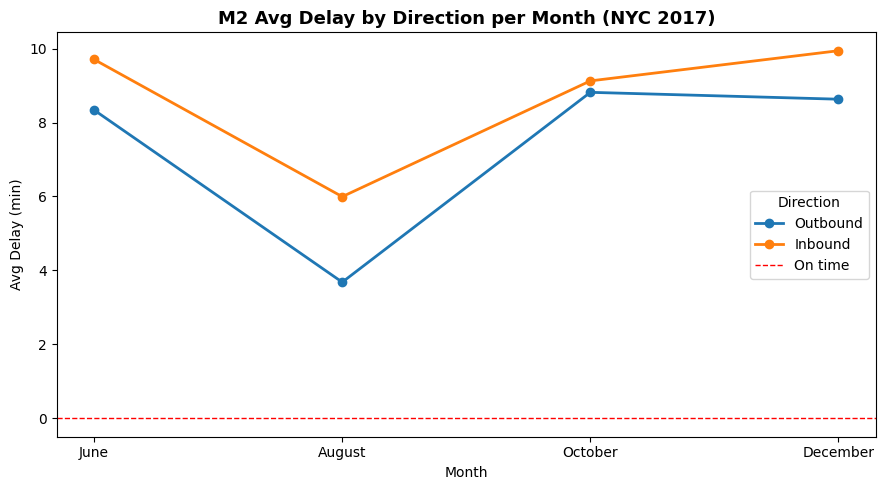

In [36]:
dir_delay = m2.groupby(['Month Name', 'DirectionRef'], observed=True)['delay_minutes'].mean().reset_index()
dir_delay['DirectionRef'] = dir_delay['DirectionRef'].map({0.0: 'Outbound', 1.0: 'Inbound'}).fillna(dir_delay['DirectionRef'].astype(str))

fig, ax = plt.subplots(figsize=(9, 5))
for direction in dir_delay['DirectionRef'].unique():
    d = dir_delay[dir_delay['DirectionRef'] == direction]
    ax.plot(d['Month Name'], d['delay_minutes'], marker='o', linewidth=2, label=direction)

ax.axhline(0, color='red', linestyle='--', linewidth=1, label='On time')
ax.set_title('M2 Avg Delay by Direction per Month (NYC 2017)', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Delay (min)')
ax.legend(title='Direction')
plt.tight_layout()
plt.savefig("m2_direction_delay.png", dpi=150)
plt.show()